In [17]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt


# Load the modelling dataset (has features + IDs)
modelling_df = pd.read_csv('../processed/modelling_dataset.csv')

# Load saved models
propensity_model = joblib.load('../outputs/best_propensity_model.pkl')
value_model = joblib.load('../outputs/best_value_model.pkl')

print(f"Dataset: {modelling_df.shape}")
print(f"Propensity model: {type(propensity_model).__name__}")
print(f"Value model: {type(value_model).__name__}")

Dataset: (83748, 37)
Propensity model: BalancedRandomForestClassifier
Value model: RandomForestRegressor


In [18]:
modelling_df.columns

Index(['customer_unique_id', 'num_orders', 'num_orders_approved',
       'num_orders_canceled', 'num_orders_created', 'num_orders_delivered',
       'num_orders_invoiced', 'num_orders_processing', 'num_orders_shipped',
       'num_orders_unavailable', 'total_payment_value',
       'total_payment_sequential', 'avg_payment_installments',
       'tot_pymt_boleto', 'tot_pymt_credit_card', 'tot_pymt_debit_card',
       'tot_pymt_voucher', 'num_products', 'num_sellers', 'avg_order_size',
       'tot_order_price', 'avg_order_price', 'tot_order_freight_value',
       'avg_order_freight_value', 'num_reviews', 'avg_review_score',
       'avg_review_title_length', 'avg_review_body_length',
       'days_since_last_purchase', 'days_since_last_shipped',
       'days_since_last_delivered', 'days_since_last_review',
       'pref_product_category', 'pref_payment_type', 'y_order_value',
       'y_propensity', 'y_order_value_log'],
      dtype='object')

In [19]:
top_10_categories = modelling_df['pref_product_category'].value_counts().head(10).index
modelling_df['pref_product_category'] = modelling_df['pref_product_category'].apply(
    lambda x: x if x in top_10_categories else 'other'
)

In [20]:
inference_df = pd.get_dummies(modelling_df, columns=['pref_product_category', 'pref_payment_type'], dtype=int)

In [21]:
drop_cols = ['tot_order_price', 'days_since_last_review', 'days_since_last_shipped',
             'avg_order_price', 'avg_order_size', 'avg_order_freight_value', 'num_orders_delivered']
inference_df = inference_df.drop(columns=[c for c in drop_cols if c in inference_df.columns])

In [22]:
customer_ids = inference_df['customer_unique_id']
target_cols = ['y_propensity', 'y_order_value', 'y_order_value_log']
X_inference = inference_df.drop(columns=['customer_unique_id'] + target_cols)

In [23]:
print(f"Inference features shape: {X_inference.shape}")
print(f"Training features had: 40 columns")
print(f"Inference features have: {X_inference.shape[1]} columns")

Inference features shape: (83748, 40)
Training features had: 40 columns
Inference features have: 40 columns


In [24]:
# Propensity scores (probability of purchase in next 90 days)
propensity_scores = propensity_model.predict_proba(X_inference)[:, 1]

# Predicted order value (log scale → convert back to dollars)
predicted_value_log = value_model.predict(X_inference)
predicted_value = np.expm1(predicted_value_log)
# Clip negative predictions to 0 (log transform can produce small negatives)
predicted_value = np.clip(predicted_value, 0, None)


In [25]:
# Expected value = propensity × predicted order value
expected_value = propensity_scores * predicted_value

In [26]:
# Build final output
output_df = pd.DataFrame({
    'customer_unique_id': customer_ids,
    'propensity_score': propensity_scores,
    'predicted_order_value': predicted_value.round(2),
    'expected_value': expected_value.round(2)
})

In [27]:
output_df = output_df.sort_values('expected_value', ascending=False).reset_index(drop=True)

print(f"Output shape: {output_df.shape}")
print(f"\nTop 10 highest-value customers:")
print(output_df.head(10))

Output shape: (83748, 4)

Top 10 highest-value customers:
                 customer_unique_id  propensity_score  predicted_order_value  \
0  1de511947aaa6cb03c498c8d7f27964d          0.625458                 158.88   
1  5449725053f76aae0e20c01f0c2160b9          0.589770                 163.58   
2  7779fdf670bfe673e064b9aa5447674e          0.687415                 137.20   
3  af51e8dd1c30737ba2dd0ece8cfa294d          0.620284                 151.76   
4  0ac10a57d07e3d38b11f66283c44672b          0.655820                 143.36   
5  9880e2d648281c53e7116caf2f735212          0.562013                 166.97   
6  6d3d5771a12f5e7d00729f940bb28fd2          0.702816                 131.92   
7  84af029e54a6f659f7ace6f7cf0daa68          0.649863                 142.58   
8  2e43e031f10de28e557c35ef668f9396          0.718116                 128.99   
9  aaf00c4cf40ae5b125c7f169dcce2fa3          0.651309                 142.16   

   expected_value  
0           99.38  
1           96.47  
2

In [28]:
print(f"\nScore distribution:")
print(output_df[['propensity_score', 'predicted_order_value', 'expected_value']].describe())


Score distribution:
       propensity_score  predicted_order_value  expected_value
count      83748.000000           83748.000000    83748.000000
mean           0.479905              89.021410       42.053757
std            0.086422              25.850929       12.468287
min            0.262100              37.320000       16.980000
25%            0.417602              68.150000       32.360000
50%            0.460485              82.200000       38.140000
75%            0.534246             111.112500       50.830000
max            0.843890             170.250000       99.380000


In [29]:
# Save the scored output
output_df.to_csv('../outputs/customer_scores.csv', index=False)
print(f"Saved customer scores: {output_df.shape}")

Saved customer scores: (83748, 4)


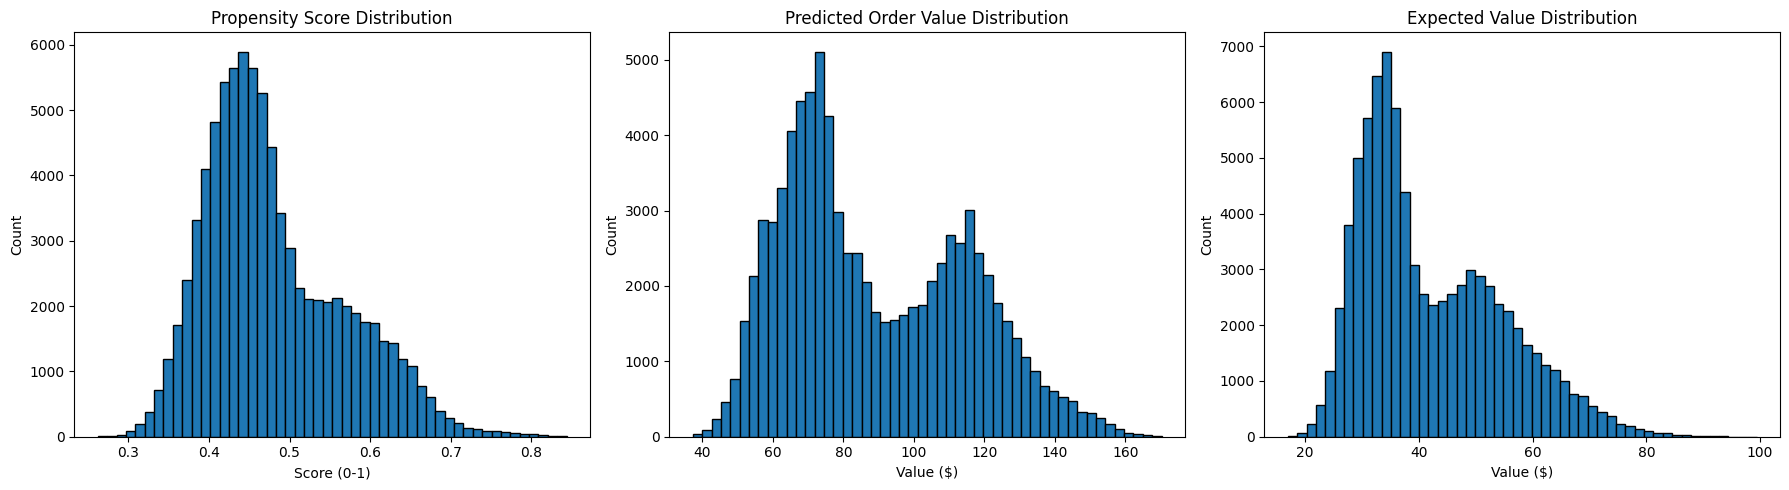

In [30]:
# Visualize score distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(output_df['propensity_score'], bins=50, edgecolor='black')
axes[0].set_title('Propensity Score Distribution')
axes[0].set_xlabel('Score (0-1)')
axes[0].set_ylabel('Count')

axes[1].hist(output_df['predicted_order_value'], bins=50, edgecolor='black')
axes[1].set_title('Predicted Order Value Distribution')
axes[1].set_xlabel('Value ($)')
axes[1].set_ylabel('Count')

axes[2].hist(output_df['expected_value'], bins=50, edgecolor='black')
axes[2].set_title('Expected Value Distribution')
axes[2].set_xlabel('Value ($)')
axes[2].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../outputs/score_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

### Inference Pipeline Summary

**Objective:** Score all 83,748 customers for purchase propensity and predicted order value.

**Models used:**
- **Propensity:** Balanced Random Forest (best ROC-AUC: 0.6171, PR-AUC: 0.0077)
- **Order Value:** Random Forest Regressor (MAE: $55.75, RMSE: $91.80)

**Output:** `customer_scores.csv` with columns:
- `propensity_score` : probability of ordering in next 90 days (0 to 1)
- `predicted_order_value` : estimated order value if they convert ($)
- `expected_value` : propensity × predicted value : used for ranking and ad targeting

**Key stats:**
- Highest expected value: $99.38
- Mean expected value: $42.05
- The top decile of customers by expected value represents the highest-priority ad targets